# Compare benchmarking timings


In [15]:
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def load_csv_files(file_paths: List[str]) -> Dict[str, pd.DataFrame]:
    """Load multiple CSV files and return a dictionary with filename as key."""
    data = {}
    for file_path in file_paths:
        path = Path(file_path)
        if not path.exists():
            print(f"Warning: File {file_path} not found, skipping...")
            continue

        df = pd.read_csv(file_path)
        # Use filename without extension as key
        key = path.stem
        data[key] = df
        print(f"Loaded {file_path}: {df.shape[0]} rows, {df.shape[1]} columns")

    return data


def get_numeric_columns(df: pd.DataFrame) -> List[str]:
    """Get all numeric columns from a dataframe."""
    return df.select_dtypes(include=[np.number]).columns.tolist()


def plot_all_columns_single_plot(
    data: Dict[str, pd.DataFrame],
    columns: List[str],
    output_dir: Path = None,
    title: str = "All Columns Comparison Across Files",
):
    """Plot all columns in one plot with one column per x-axis entry."""
    fig, ax = plt.subplots(figsize=(14, 8))

    file_labels = list(data.keys())
    num_files = len(file_labels)
    num_columns = len(columns)

    x_pos = np.arange(num_columns)
    width = 0.8 / num_files

    # Get reference values if multiple files
    reference_means = None
    if num_files > 1:
        reference_df = data[file_labels[0]]
        reference_means = []
        for column in columns:
            if column not in reference_df.columns:
                reference_means.append(None)
            else:
                values = reference_df[column].dropna()
                reference_means.append(values.mean())

    for file_idx, (label, df) in enumerate(data.items()):
        means = []
        stds = []

        for column in columns:
            if column not in df.columns:
                print(f"Warning: Column '{column}' not found in {label}")
                means.append(0)
                stds.append(0)
            else:
                values = df[column].dropna()
                means.append(values.mean())
                stds.append(values.std())

        offset = (file_idx - num_files / 2 + 0.5) * width
        bars = ax.bar(
            x_pos + offset,
            means,
            width,
            label=label,
            yerr=stds,
            capsize=4,
            alpha=0.8,
        )

        # Add speedup labels on top of bars if multiple files
        if num_files > 1 and file_idx > 0 and reference_means is not None:
            for col_idx, (bar, mean) in enumerate(zip(bars, means)):
                if (
                    reference_means[col_idx] is not None
                    and reference_means[col_idx] != 0
                    and mean != 0
                ):
                    speedup = reference_means[col_idx] / mean
                    height = bar.get_height()
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height * 1.20,
                        f"{speedup:.2f}x",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        fontweight="bold",
                    )

    ax.set_xlabel("Program Sections")
    ax.set_ylabel("Accumulated walltime (mean ± std) [us]")
    ax.set_title(title)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_yscale("log")

    plt.tight_layout()

    if output_dir:
        output_path = output_dir / "15k_200_iterations.png"
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()

Loaded evac_shortest_path_HEAD_15k.csv: 50 rows, 7 columns
Loaded evac_shortest_path_deque_ptr_15k_flt.csv: 50 rows, 7 columns
Loaded evac_shortest_path_deque_ptr_15k.csv: 50 rows, 7 columns


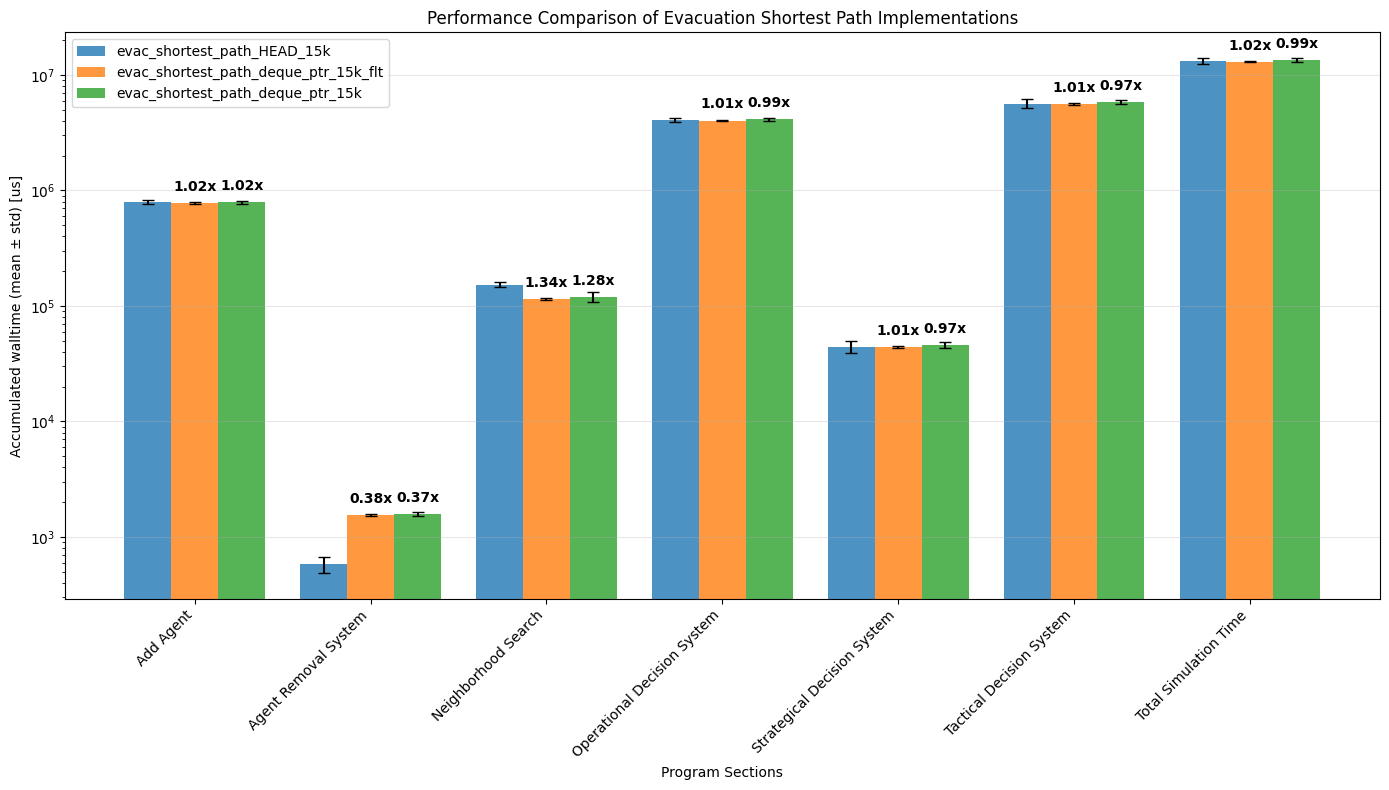

In [ ]:
plot_title = (
    "Performance Comparison of Evacuation Shortest Path Implementations"
)

file_list = [
    "evac_shortest_path_HEAD_15k.csv",
    "evac_shortest_path_deque_ptr_15k_flt.csv",
    "evac_shortest_path_deque_15k.csv",
]


def main(output_dir: Path = None, columns: List[str] = None):
    data = load_csv_files(file_list)

    if not data:
        print("No valid data loaded. Exiting.")
        return

    # Get numeric columns from the first loaded dataframe
    first_key = next(iter(data))
    numeric_columns = get_numeric_columns(data[first_key])

    if not numeric_columns:
        print("No numeric columns found in the data. Exiting.")
        return

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True)

    if columns is None:
        columns = numeric_columns

    plot_all_columns_single_plot(
        data,
        columns,
        output_dir=output_dir,
        title=plot_title,
    )


main()